In [1]:
import numpy as np
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df=pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [4]:
df.head(1)
# focus is on -> areaWithType, additional room, agePossession, furnishDetails, features

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,independent,sector 4,3.25,14444.0,2250.0,Plot area 250(209.03 sq.m.),3,3,2,not available,2.0,South-East,10+ Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Prateek Nursing Home And Polyclinic', 'Kr Dental Hub', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Sarvodya Hospital', 'Sneh Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Dr. Ashok Jain', 'Gurgaon Eye Centre', 'Dr. Sindhu Clinic', 'Pearl Dental Clinic', 'Dr. Hitesh Dawar', 'Dr. Mittal Clinic', 'Jiya Clinic', 'Aryan Hospital', 'Yashroop Medical Centre', 'Taneja Hospital', ""Dr. Anurag's Child Care Clinic"", 'Esic Hospital Gurugram', 'D.R. Rajnis Gupta Clinic', 'Geeta Nursing Home Gurgaon', 'Sparsh Hospital Gurgaon', 'Bhardwaj Hospital', 'Ravi Clinic and Health Care Centre', 'Bhatnagar Maternity and Nursing Home', 'Chiranjiv Hospital', 'Dr. Agya Ram Sharma Clinic', 'GH Gurgaon', 'Dr. Madan Clinic', 'Bindal Clinic', 'Dr. Sarvejeet Singh', 'R K Hospital Gurgaon', 'Dev Man Kathuria Clinic', 'Swastik Maternity and Medical Centre', 'Centre For Sight Gurgaon New Railway Road', 'M.S Hospital', 'My Care Clinic', 'Kidney Clinic', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'State bank of india', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['30 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Park', 'Visitor Parking', 'Low Density Society']"


In [5]:
df.shape

(3805, 17)

# 1.areaWithType

In [6]:
df[['price','area','areaWithType']].sample(5)

,price,area,areaWithType
2644,0.87,450.0,Carpet area: 450 (41.81 sq.m.)
3008,0.90,900.0,Plot area 900(83.61 sq.m.)Built Up area: 3500 sq.ft. (325.16 sq.m.)
1093,0.35,500.0,Super Built up area 567(52.68 sq.m.)Built Up area: 556 sq.ft. (51.65 sq.m.)Carpet area: 500 sq.ft. (46.45 sq.m.)
1378,0.78,1295.0,Super Built up area 1295(120.31 sq.m.)
3315,1.10,958.0,Super Built up area 89


In [7]:
import re

In [8]:
# Function to extract Super Built up area
def get_super_built_up_area(text):
  match=re.search(r'Super Built up area (\d+\.?\d*)',text)
  if match:
    return float(match.group(1))
  else:
    return None

In [9]:
# Function to Built up area or Carpet area
def get_area(text,area_type):
  match=re.search(area_type + r'\s*:\s*(\d+\.?\d*)',text)
  if match:
    return float(match.group(1))
  else:
    return None

In [10]:
# Function to check the unit, if it is in sq.m. it will cange to sqft
def conv_to_sqft(text,area_value):
  if area_value is None:
    return None
  match=re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
  if match:
    sq_m_value = float(match.group(1))
    return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
  return area_value

In [11]:
df['super_built_up_area']=df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area']=df.apply(lambda x: conv_to_sqft(x['areaWithType'],x['super_built_up_area']),axis=1)

In [12]:
df['built_up_area']=df['areaWithType'].apply(get_area,area_type='Built Up area')
df['built_up_area']=df.apply(lambda x: conv_to_sqft(x['areaWithType'],x['built_up_area']),axis=1)

In [13]:
df['carpet_area']=df['areaWithType'].apply(get_area,area_type='Carpet area')
df['carpet_area']=df.apply(lambda x: conv_to_sqft(x['areaWithType'],x['carpet_area']),axis=1)

In [14]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2165,0.21,flat,484.0,Built Up area: 484 (44.97 sq.m.),NaN,484.0,NaN
3185,1.92,flat,2000.0,Carpet area: 2000 (185.81 sq.m.),NaN,NaN,2000.0
2085,1.33,flat,783.0,Built Up area: 1423 (132.2 sq.m.)Carpet area: 783 sq.ft. (72.74 sq.m.),NaN,1423.0,783.0
2440,1.71,flat,1425.0,Built Up area: 1423 (132.2 sq.m.),NaN,1423.0,NaN
1251,7.50,house,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 sq.yards (201.51 sq.m.)Carpet area: 240 sq.yards (200.67 sq.m.),NaN,241.0,240.0


In [15]:
df[~(df['super_built_up_area'].isnull()|df['built_up_area'].isnull()|df['carpet_area'].isnull())][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [16]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(682, 7)

In [17]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,17
price_per_sqft,17
area,17
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [18]:
all_nan_df=df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3716,3.20,house,2230.0,Plot area 2160(200.67 sq.m.),NaN,NaN,NaN
1366,NaN,house,NaN,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
1330,11.25,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
2916,1.83,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
3072,0.75,house,640.0,Plot area 640(59.46 sq.m.),NaN,NaN,NaN


In [19]:
all_nan_df.shape

(546, 7)

In [20]:
all_nan_index=all_nan_df.index

In [21]:
#function to extract plot area from'areaWithType'
def extract_plot_area(text):
  match=re.search(r'Plot area (\d+\.?\d*)',text)
  return float(match.group(1)) if match else None

In [22]:
all_nan_df['built_up_area']=all_nan_df['areaWithType'].apply(extract_plot_area)

In [23]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3177,0.70,house,1160.0,Plot area 1160(107.77 sq.m.),NaN,1160.0,NaN
992,16.00,house,4500.0,Plot area 500(418.06 sq.m.),NaN,500.0,NaN
3504,1.07,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.0,NaN
1014,3.25,house,1512.0,Plot area 168(140.47 sq.m.),NaN,168.0,NaN
3343,6.25,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.0,NaN


In [24]:
all_nan_df['built_up_area'].isnull().sum()

np.int64(0)

In [25]:
def convert_scale(row):
  if np.isnan(row['area']) :
    return row['built_up_area']
  else:
    if round((row['area']/row['built_up_area'])) == 9.0 :
      return row['built_up_area']*9
    if round((row['area']/row['built_up_area'])) == 11.0 :
      return row['built_up_area']*10.7
    return row['built_up_area']

In [26]:
all_nan_df['built_up_area']=all_nan_df.apply(convert_scale,axis=1)

In [27]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
643,5.6,house,4000.0,Plot area 4000(371.61 sq.m.),NaN,4000.0,NaN
3387,11.5,house,4680.0,Plot area 520(434.79 sq.m.),NaN,4680.0,NaN
1452,10.0,house,250.0,Plot area 250(23.23 sq.m.),NaN,250.0,NaN
1680,2.5,house,3194.0,Plot area 3194(296.73 sq.m.),NaN,3194.0,NaN
3177,0.7,house,1160.0,Plot area 1160(107.77 sq.m.),NaN,1160.0,NaN


In [28]:
df.update(all_nan_df)

# 2.additionalRoom

In [29]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
not available,1589
servant room,705
study room,250
others,225
pooja room,165
store room,99
"study room,servant room",99
"pooja room,servant room",82
"pooja room,study room,servant room,store room",72


In [30]:
new_cols=['study room','servant room','store room','pooja room','others']
for col in new_cols:
  df[col]=df['additionalRoom'].str.contains(col).astype(int)

In [31]:
df[['additionalRoom','study room','servant room','store room','pooja room','others']].sample(5)

,additionalRoom,study room,servant room,store room,pooja room,others
1385,not available,0,0,0,0,0
2858,not available,0,0,0,0,0
784,not available,0,0,0,0,0
190,not available,0,0,0,0,0
2135,"store room,pooja room,servant room,study room",1,1,1,1,0


# 3.agePossessition

In [32]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,1676
5 to 10 Year Old,575
0 to 1 Year Old,530
undefined,335
10+ Year Old,310
Under Construction,89
Within 6 months,70
Within 3 months,26
Dec-23,20


In [33]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        try:
          # For entries like 'Mar-2026'
          int(value.split("-")[-1])
          return "Under Construction"
        except:
          return "Undefined"

In [34]:
df['agePossession']=df['agePossession'].apply(categorize_age_possession)

In [35]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1676
New Property,626
Moderately Old,575
Undefined,336
Old Property,310
Under Construction,282


# 4.furnishDetails

In [36]:
df.head()[['furnishDetails','features']]

,furnishDetails,features
0,"['30 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Park', 'Visitor Parking', 'Low Density Society']"
1,"['4 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '10 Light', '1 Modular Kitchen', '4 AC', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
3,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
4,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN


In [37]:
# Extract all furnishing
all_furnishings=[]
for detail in df['furnishDetails'].dropna():
  all_furnishings.extend(detail.replace('[','').replace(']','').replace("'","").split(', '))
all_furnishings=list(set(all_furnishings))
del all_furnishings[0] # remove empty string (if the dataset need to upload again the location need to change )
all_furnishings
unique_furnishings=[]
for furnishing in all_furnishings:
  unique_furnishings.append(furnishing.split(' ')[1])
unique_furnishings=list(set(unique_furnishings))
unique_furnishings

['AC',
 'TV',
 'Washing',
 'Sofa',
 'Geyser',
 'Water',
 'Exhaust',
 'Modular',
 'Bed',
 'Fridge',
 'Fan',
 'Light',
 'Microwave',
 'Curtains',
 'Dining',
 'Stove',
 'Chimney',
 'Wardrobe']

In [38]:
# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details,str):
      if f"No {furnishing}" in details:
        return 0
      pattern=re.compile(f"(\d+) {furnishing}")
      match=pattern.search(details)
      if match:
        return int(match.group(1))
      elif furnishing in details:
        return 1
    return 0

# Create new coln for furnishing
for furnishing in unique_furnishings:
  df[furnishing]=df['furnishDetails'].apply(get_furnishing_count,furnishing=furnishing)

# Create new dataframe with the required coln
df_furnishings=df[['furnishDetails']+unique_furnishings]

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4436/1097412087.py:6: SyntaxWarning: invalid escape sequence '\d'
  pattern=re.compile(f"(\d+) {furnishing}")


In [39]:
df_furnishings.shape

(3805, 19)

In [40]:
df_furnishings.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipykernel_4436/3496268856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_furnishings.drop(columns=['furnishDetails'],inplace=True)


In [41]:
df_furnishings.sample(5)

,AC,TV,Washing,Sofa,Geyser,Water,Exhaust,Modular,Bed,Fridge,Fan,Light,Microwave,Curtains,Dining,Stove,Chimney,Wardrobe
1792,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2185,6,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
641,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3057,0,0,0,0,1,1,1,1,2,0,4,4,0,1,0,0,0,2
2136,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,1,3


In [42]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [43]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df_furnishings)

In [44]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

In [45]:
wcss

[68490.00000000063,
 51975.47574242528,
 41909.456553328535,
 39022.18946715718,
 35981.42485749537,
 35224.78207596147,
 32644.13980230589,
 31168.542220114425,
 30317.80753828584,
 28632.303249033434]

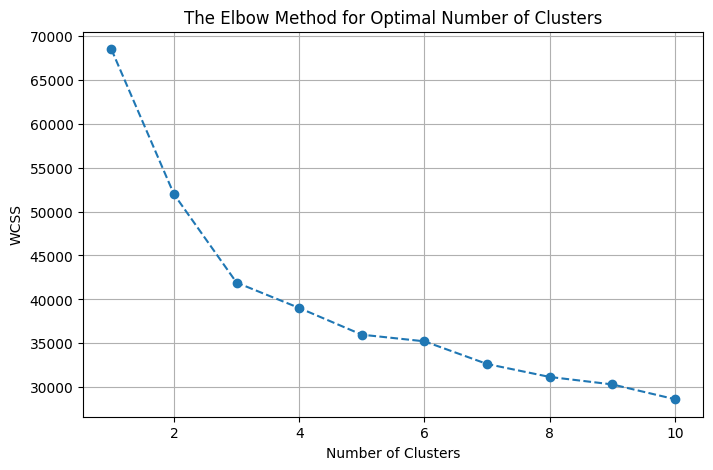

In [46]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('The Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [47]:
n_clusters=3

# Fit the KMeans model
kmeans=KMeans(n_clusters=n_clusters,random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments=kmeans.predict(scaled_data)
cluster_assignments

array([1, 2, 1, ..., 1, 0, 2], dtype=int32)

In [48]:
df=df.iloc[:,:-18]

In [49]:
# Add the cluster assignments to the original DataFrame
df['furnishing_type']=cluster_assignments

In [50]:
df[['furnishDetails','furnishing_type']].sample(5)
# 0 -> furnished
# 1 -> unfurnished
# 2 -> semifernished

,furnishDetails,furnishing_type
3420,NaN,1
3323,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '10 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
1665,"['1 Exhaust Fan', '1 Stove', '1 Light', '1 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
1046,"['4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
2831,"['1 Water Purifier', '1 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '1 Light', '1 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '1 Wardrobe', 'No Bed', 'No Geyser', 'No Microwave', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']",0


In [51]:
# swap the  values of furnishing_type
def swap_values(value):
  if value==0:
    return 2
  elif value==1:
    return 0
  else:
    return 1

In [52]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> fernished
df['furnishing_type']=df['furnishing_type'].apply(swap_values)

In [53]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
0,2511
1,1078
2,216


# 5.features

In [54]:
df[['society','features']].sample(5)

,society,features
2907,smart world orchard,"['Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Park', 'Visitor Parking']"
620,shapoorji pallonji joyville gurugram,NaN
2958,microtek greenburg,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Visitor Parking', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2635,conscient heritage max,"['Power Back-up', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Water Storage', 'Park', 'Fitness Centre / GYM', 'Club house / Community Center']"
815,signature global infinity mall,NaN


In [55]:
df['features'].isnull().sum()

np.int64(638)

In [56]:
app_df=pd.read_csv('appartments.csv')
app_df.sample()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
238,DLF New Town Heights,"2, 3, 4 BHK Apartment in Sector 91, Gurgaon","['KLAY Play School', 'RHM Public School', 'Sanjeevani Hospital', 'Garhi Harsaru Junction', 'Spaze Business Park']","{'KLAY Play School': '1.7 KM', 'RHM Public School': '2.1 KM', 'Sanjeevani Hospital': '2.5 KM', 'Garhi Harsaru Junction': '5.9 KM', 'Spaze Business Park': '21.4 KM', 'Orchid Business Park': '21.5 KM', 'MG Road Metro Station': '25.6 KM', 'IGI Airport': '35.3 KM'}",https://www.99acres.com/dlf-new-town-heights-sector-91-gurgaon-npxid-r23702,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,615 sq.ft.', 'price-range': '₹ 99.35 L'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,845 - 1,930 sq.ft.', 'price-range': '₹ 1.14 - 1.19 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,230 - 2,727 sq.ft.', 'price-range': '₹ 1.37 - 1.68 Cr'}}","['Swimming Pool', 'Sauna', 'Piped Gas', 'Grocery Shop', 'Squash Court', 'Fountain', 'Lawn Tennis Court', 'Video Door Security', 'Earthquake Resistant']"


In [57]:
app_df['PropertyName']=app_df['PropertyName'].str.lower()

In [58]:
temp_df=df[df['features'].isnull()]

In [59]:
temp_df.shape

(638, 26)

In [60]:
x=temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [61]:
df.loc[temp_df.index,'features']=x.values

In [62]:
df['features'].isnull().sum()

np.int64(485)

In [63]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [64]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [65]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
788,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
998,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
941,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
952,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
642,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0


In [66]:
features_binary_df.shape

(3805, 130)

In [67]:
wcss=[]

for i in range (1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(features_binary_df)
  wcss.append(kmeans.inertia_)

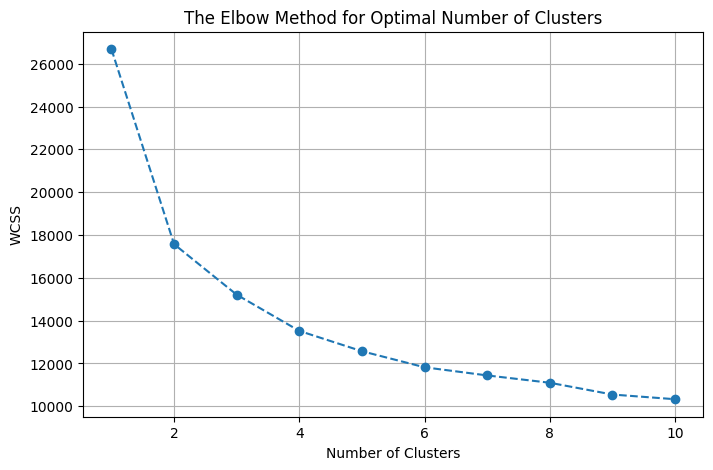

In [68]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('The Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [69]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [70]:
df['luxury_score']=luxury_score

In [71]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,independent,sector 4,3.25,14444.0,2250.0,Plot area 250(209.03 sq.m.),3,3,2,not available,2.0,South-East,Old Property,"['Chintapurni Mandir', 'State bank ATM', 'Prateek Nursing Home And Polyclinic', 'Kr Dental Hub', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Sarvodya Hospital', 'Sneh Hospital Gurgaon', 'Shree Krishna Hospital Gurgaon', 'Dr. Ashok Jain', 'Gurgaon Eye Centre', 'Dr. Sindhu Clinic', 'Pearl Dental Clinic', 'Dr. Hitesh Dawar', 'Dr. Mittal Clinic', 'Jiya Clinic', 'Aryan Hospital', 'Yashroop Medical Centre', 'Taneja Hospital', ""Dr. Anurag's Child Care Clinic"", 'Esic Hospital Gurugram', 'D.R. Rajnis Gupta Clinic', 'Geeta Nursing Home Gurgaon', 'Sparsh Hospital Gurgaon', 'Bhardwaj Hospital', 'Ravi Clinic and Health Care Centre', 'Bhatnagar Maternity and Nursing Home', 'Chiranjiv Hospital', 'Dr. Agya Ram Sharma Clinic', 'GH Gurgaon', 'Dr. Madan Clinic', 'Bindal Clinic', 'Dr. Sarvejeet Singh', 'R K Hospital Gurgaon', 'Dev Man Kathuria Clinic', 'Swastik Maternity and Medical Centre', 'Centre For Sight Gurgaon New Railway Road', 'M.S Hospital', 'My Care Clinic', 'Kidney Clinic', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'State bank of india', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['30 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Park', 'Visitor Parking', 'Low Density Society']",NaN,2250.0,NaN,0,0,0,0,0,0,"[Feng Shui / Vaastu Compliant, Park, Visitor Parking, Low Density Society]",27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3+,"pooja room,servant room",9.0,South-West,Moderately Old,"['Omaxe City Centre Mall', 'Golf Course Extension Road', ""St. Xavier's School"", 'KIIT College of Engineering', 'Ektaa Hospital', 'Indira Gandhi International Airport', 'Surajgarh Gurgaon', 'Duke Horse Riding Club', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park', 'HUDA Mini Golf Course', 'PVR Drive In Theater']","['4 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '10 Light', '1 Modular Kitchen', '4 AC', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2350.0,NaN,NaN,0,1,0,1,0,1,"[Centrally Air Conditioned, Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Piped-gas, Internet/wi-fi connectivity, Visitor Parking, Swimming Pool, Park, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Waste Disposal, Rain Water Harvesting, Water softening plant, Shopping Centre, Fitness Centre / GYM, Club ho

In [72]:
# coln to drop -> nearbyLocations, furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [73]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
452,flat,spaze privvy the address,sector 93,1.25,5701.0,2193.0,Built Up area: 2105 (195.56 sq.m.)Carpet area: 1700 sq.ft. (157.94 sq.m.),4,4,3,16.0,NaN,Relatively New,NaN,2105.0,1700.0,0,0,0,0,0,0,0
2348,flat,emaar mgf palm studios,sector 66,1.70,13502.0,1259.0,Super Built up area 1185(110.09 sq.m.),2,2,2,7.0,NaN,Relatively New,1185.0,NaN,NaN,0,0,0,0,1,0,99
3394,flat,piedmont taksila heights,sector 37c,1.00,6506.0,1537.0,Carpet area: 1537 (142.79 sq.m.),3,3,3+,8.0,NaN,Relatively New,NaN,NaN,1537.0,0,0,0,0,0,1,49
393,flat,ats marigold,sector 89,1.70,9714.0,1750.0,Carpet area: 1750 (162.58 sq.m.),3,3,3+,8.0,North,Under Construction,NaN,NaN,1750.0,1,0,0,0,0,0,65
307,flat,signature global solera,sector 107,0.35,6489.0,539.0,Carpet area: 547 (50.82 sq.m.),2,2,2,8.0,North-West,Relatively New,NaN,NaN,547.0,0,0,0,0,0,0,45


In [74]:
df.shape

(3805, 23)

In [75]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)